In [ ]:
#  Diabetes Risk Prediction & Healthcare Analytics

### An End-to-End Machine Learning Analysis Using CDC Health Indicators

---

###  Project Overview

This project develops an end-to-end machine learning workflow for analyzing
health and lifestyle indicators associated with diabetes-related outcomes.

The project covers:

- Data loading and validation
- Data quality assessment
- Exploratory Data Analysis (EDA)
- Health indicator analysis
- Class imbalance analysis
- Data preprocessing
- Machine learning model development
- Cross-validation
- Model comparison
- Confusion matrix analysis
- ROC-AUC and Precision-Recall analysis
- Feature importance and model interpretability
- Error analysis
- Overfitting and underfitting analysis
- Final insights and limitations

###  Objective

To develop and evaluate machine learning classification models that can
identify patterns associated with diabetes/prediabetes status using
healthcare, lifestyle, demographic, and behavioral indicators.

>  This project is intended for educational and analytical purposes.
> It is not a medical diagnostic system and should not be used to diagnose
> or make treatment decisions for individuals.

###  Dataset

Source: CDC Diabetes Health Indicators Dataset  
Original repository: UCI Machine Learning Repository

The dataset contains health-related survey indicators collected through
the Behavioral Risk Factor Surveillance System (BRFSS).

###  Machine Learning Approach

The project evaluates multiple classification algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models are evaluated using multiple metrics rather than relying only
on accuracy.

---

**Author:** Rohan Bhowmik  
**Domain:** Data Science with Python  
**Project:** Week 4 — Machine Learning Model Development & Evaluation

In [ ]:
## 1. Business & Analytical Problem

Diabetes is influenced by a combination of demographic, lifestyle,
behavioral, and health-related factors.

From a data science perspective, the challenge is to determine whether
patterns within these indicators can be used to classify observations
according to diabetes-related status.

### Key Questions

- What health indicators are associated with diabetes-related outcomes?
- Is the target variable balanced?
- Which machine learning model performs best across multiple metrics?
- Which features contribute most strongly to model predictions?
- Where does the model make classification errors?
- Are there signs of overfitting or underfitting?
- What improvements could make the analysis more robust?

The objective is not simply to maximize accuracy, but to critically
evaluate model performance and understand its limitations.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display, HTML

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Professional notebook styling

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 110

display(HTML("""
<div style="
    padding:20px;
    border-radius:12px;
    background:#f4f7fb;
    border-left:6px solid #2f6fed;
    margin-bottom:15px;
">
<h2 style="margin:0;">🩺 Diabetes Risk Prediction</h2>
<p style="margin-top:8px;">
Professional end-to-end machine learning workflow
</p>
</div>
"""))

In [10]:
# ============================================================
# CELL 5 — LOAD DIABETES DATASET
# ============================================================

import pandas as pd
from pathlib import Path

# Search the entire Documents folder for the CSV file
documents_folder = Path.home() / "Documents"

csv_files = list(documents_folder.rglob("diabetes_binary_health_indicators_BRFSS2015.csv"))

if len(csv_files) == 0:
    print(" CSV file was not found inside the Documents folder.")
    print("\nCSV files found in Documents:")
    
    all_csv_files = list(documents_folder.rglob("*.csv"))
    
    if all_csv_files:
        for file in all_csv_files:
            print("📄", file)
    else:
        print("No CSV files were found inside Documents.")
        
else:
    file_path = csv_files[0]
    
    print(" CSV file found!")
    print(" Location:", file_path)
    
    # Load dataset
    df = pd.read_csv(file_path)
    
    print("\n Dataset loaded successfully!")
    print("Dataset Shape:", df.shape)
    
    display(df.head())

 CSV file found!
 Location: C:\Users\rohan bhowmik\Documents\diabetes_binary_health_indicators_BRFSS2015.csv

 Dataset loaded successfully!
Dataset Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [11]:
# First look at the dataset

display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Dataset shape: (253680, 22)

Column names:
01. Diabetes_binary
02. HighBP
03. HighChol
04. CholCheck
05. BMI
06. Smoker
07. Stroke
08. HeartDiseaseorAttack
09. PhysActivity
10. Fruits
11. Veggies
12. HvyAlcoholConsump
13. AnyHealthcare
14. NoDocbcCost
15. GenHlth
16. MentHlth
17. PhysHlth
18. DiffWalk
19. Sex
20. Age
21. Education
22. Income


In [ ]:
## 2. Dataset Understanding

The dataset contains binary, ordinal, and numerical health indicators.

The target variable is:

**`Diabetes_binary`**

- `0` → No diabetes
- `1` → Prediabetes or diabetes

The predictor variables describe areas such as:

- Blood pressure
- Cholesterol
- BMI
- Smoking
- Stroke history
- Heart disease
- Physical activity
- Fruit and vegetable consumption
- General health
- Mental health
- Physical health
- Mobility difficulty
- Demographic indicators
- Education
- Income

In [12]:
# Dataset structure and data types

print("DATA TYPES")
print("=" * 60)

display(
    pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Unique Values": [df[col].nunique() for col in df.columns],
        "Missing Values": [df[col].isna().sum() for col in df.columns]
    })
)

DATA TYPES


,Column,Data Type,Unique Values,Missing Values
0,Diabetes_binary,float64,2,0
1,HighBP,float64,2,0
2,HighChol,float64,2,0
3,CholCheck,float64,2,0
4,BMI,float64,84,0
5,Smoker,float64,2,0
6,Stroke,float64,2,0
7,HeartDiseaseorAttack,float64,2,0
8,PhysActivity,float64,2,0
9,Fruits,float64,2,0


In [13]:
# Data quality assessment

quality_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes.astype(str)
})

display(quality_report)

print("Duplicate rows:", df.duplicated().sum())

,Missing Values,Missing %,Unique Values,Data Type
Diabetes_binary,0,0.0,2,float64
HighBP,0,0.0,2,float64
HighChol,0,0.0,2,float64
CholCheck,0,0.0,2,float64
BMI,0,0.0,84,float64
Smoker,0,0.0,2,float64
Stroke,0,0.0,2,float64
HeartDiseaseorAttack,0,0.0,2,float64
PhysActivity,0,0.0,2,float64
Fruits,0,0.0,2,float64


Duplicate rows: 24206


In [ ]:
## 3. Data Quality Findings

Before modeling, the dataset is checked for:

- Missing values
- Duplicate observations
- Incorrect data types
- Constant columns
- Unexpected values
- Target distribution

This step is important because machine learning models are sensitive to
data quality and incorrect preprocessing can lead to misleading results.

In [14]:
# Remove exact duplicate rows if present

duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {duplicate_count:,} duplicate rows.")
else:
    print("No duplicate rows found.")

print("Updated shape:", df.shape)

Removed 24,206 duplicate rows.
Updated shape: (229474, 22)


In [15]:
# Statistical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,229474.0,0.152945,0.359936,0.0,0.0,0.0,0.0,1.0
HighBP,229474.0,0.454343,0.497912,0.0,0.0,0.0,1.0,1.0
HighChol,229474.0,0.441640,0.496584,0.0,0.0,0.0,1.0,1.0
CholCheck,229474.0,0.959481,0.197173,0.0,1.0,1.0,1.0,1.0
BMI,229474.0,28.687507,6.789204,12.0,24.0,27.0,32.0,98.0
Smoker,229474.0,0.465800,0.498830,0.0,0.0,0.0,1.0,1.0
Stroke,229474.0,0.044816,0.206899,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,229474.0,0.103336,0.304398,0.0,0.0,0.0,0.0,1.0
PhysActivity,229474.0,0.733042,0.442371,0.0,0.0,1.0,1.0,1.0
Fruits,229474.0,0.612675,0.487140,0.0,0.0,1.0,1.0,1.0


,Count,Percentage
Diabetes_binary,,
0.0,194377,84.71
1.0,35097,15.29


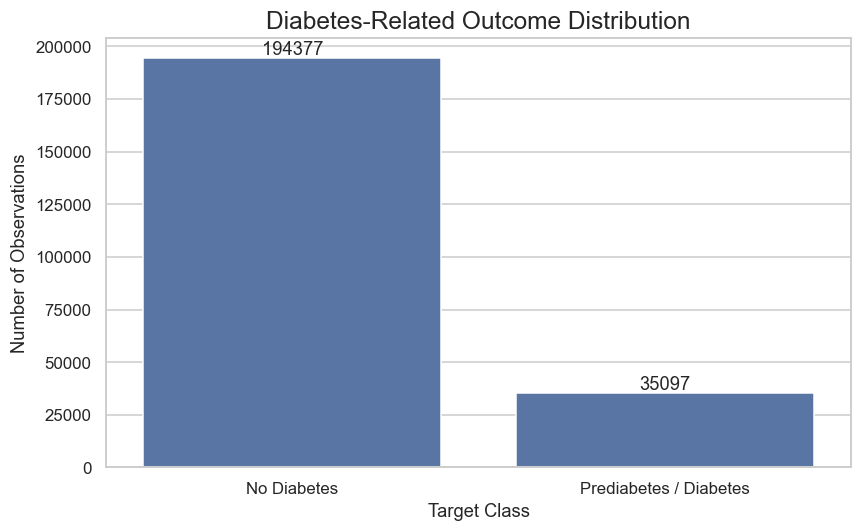

In [16]:
# Target distribution

target_counts = df["Diabetes_binary"].value_counts().sort_index()
target_percent = df["Diabetes_binary"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

display(target_summary)

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title("Diabetes-Related Outcome Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Observations")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.xticks(
    [0, 1],
    ["No Diabetes", "Prediabetes / Diabetes"]
)

plt.tight_layout()
plt.show()

In [ ]:
## 4. Class Imbalance Analysis

The target distribution is examined before model training.

This is particularly important because a model can achieve a seemingly
high accuracy simply by favoring the majority class.

Therefore, this project will evaluate:

- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision
- Confusion Matrix

rather than using accuracy alone.

In [17]:
# Identify feature groups

target = "Diabetes_binary"

X = df.drop(columns=[target])
y = df[target]

binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

numeric_or_ordinal_features = [
    "BMI",
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income"
]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nBinary features:", len(binary_features))
print("Numeric/ordinal features:", len(numeric_or_ordinal_features))

Feature matrix shape: (229474, 21)
Target shape: (229474,)

Binary features: 14
Numeric/ordinal features: 7


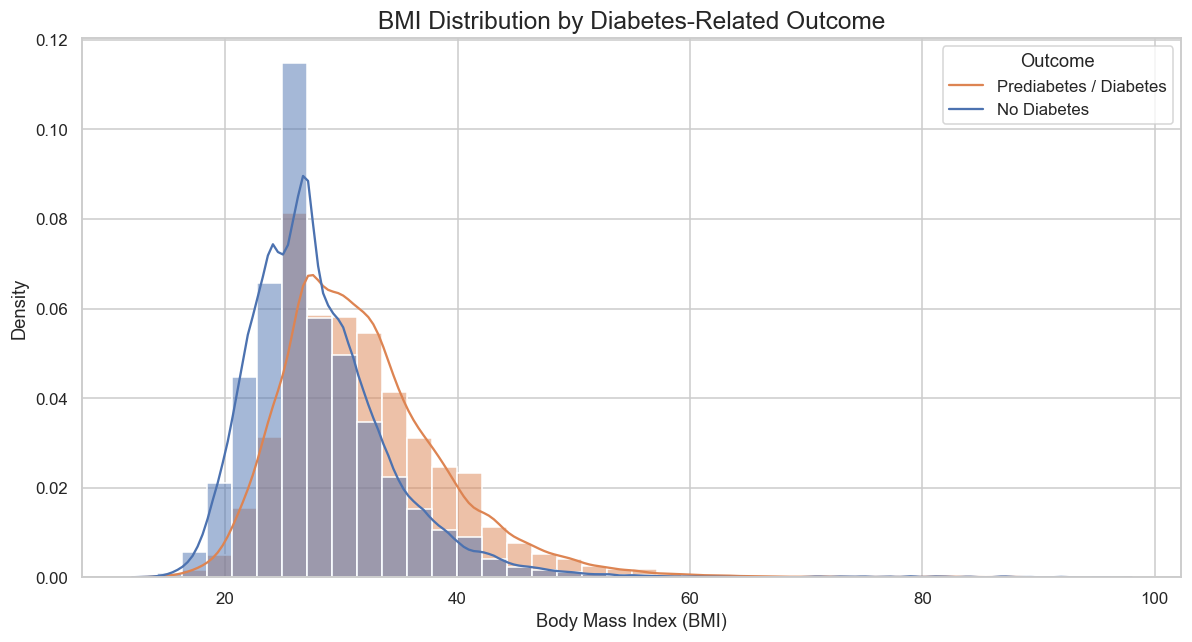

In [18]:
# BMI distribution by target class

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df,
    x="BMI",
    hue="Diabetes_binary",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("BMI Distribution by Diabetes-Related Outcome")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Density")

plt.legend(
    title="Outcome",
    labels=["Prediabetes / Diabetes", "No Diabetes"]
)

plt.tight_layout()
plt.show()

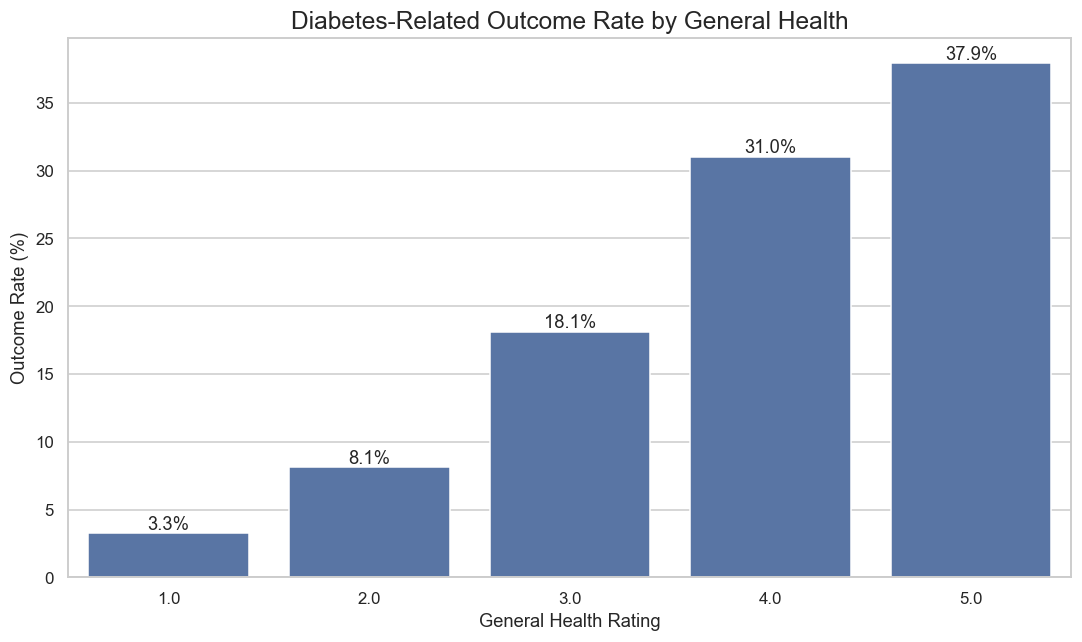

In [19]:
# General health vs diabetes-related outcome

health_rate = (
    df.groupby("GenHlth")["Diabetes_binary"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=health_rate.index,
    y=health_rate.values
)

plt.title("Diabetes-Related Outcome Rate by General Health")
plt.xlabel("General Health Rating")
plt.ylabel("Outcome Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

Diabetes_binary,No Diabetes,Prediabetes / Diabetes
HighBP,40.05,75.23
HighChol,40.05,66.95
HeartDiseaseorAttack,8.16,22.38
Stroke,3.61,9.31
PhysActivity,75.19,62.85
Smoker,45.62,51.92
DiffWalk,15.18,37.37


<Figure size 1320x770 with 0 Axes>

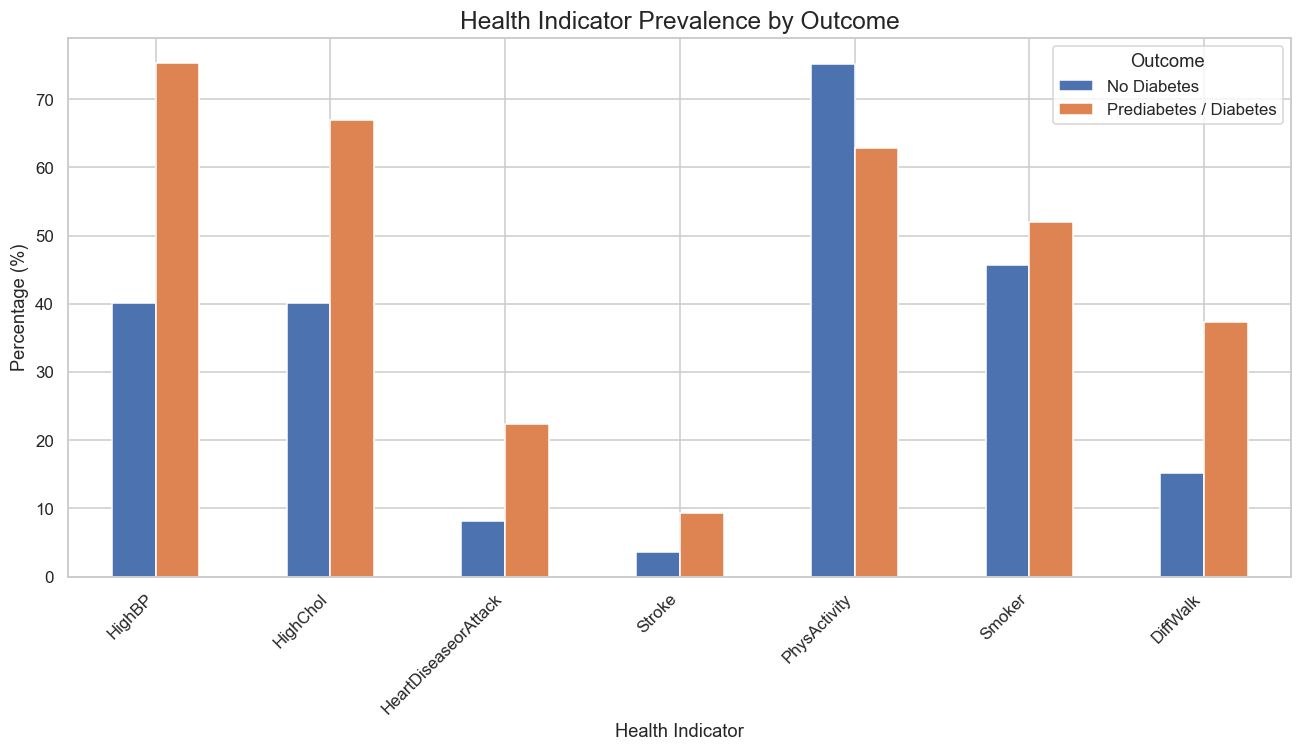

In [20]:
# Selected health indicator comparison

selected_features = [
    "HighBP",
    "HighChol",
    "HeartDiseaseorAttack",
    "Stroke",
    "PhysActivity",
    "Smoker",
    "DiffWalk"
]

indicator_rates = (
    df.groupby("Diabetes_binary")[selected_features]
    .mean()
    .T
    .rename(columns={
        0: "No Diabetes",
        1: "Prediabetes / Diabetes"
    })
)

display(
    (indicator_rates * 100).round(2)
)

plt.figure(figsize=(12, 7))

indicator_rates.mul(100).plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Health Indicator Prevalence by Outcome")
plt.xlabel("Health Indicator")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

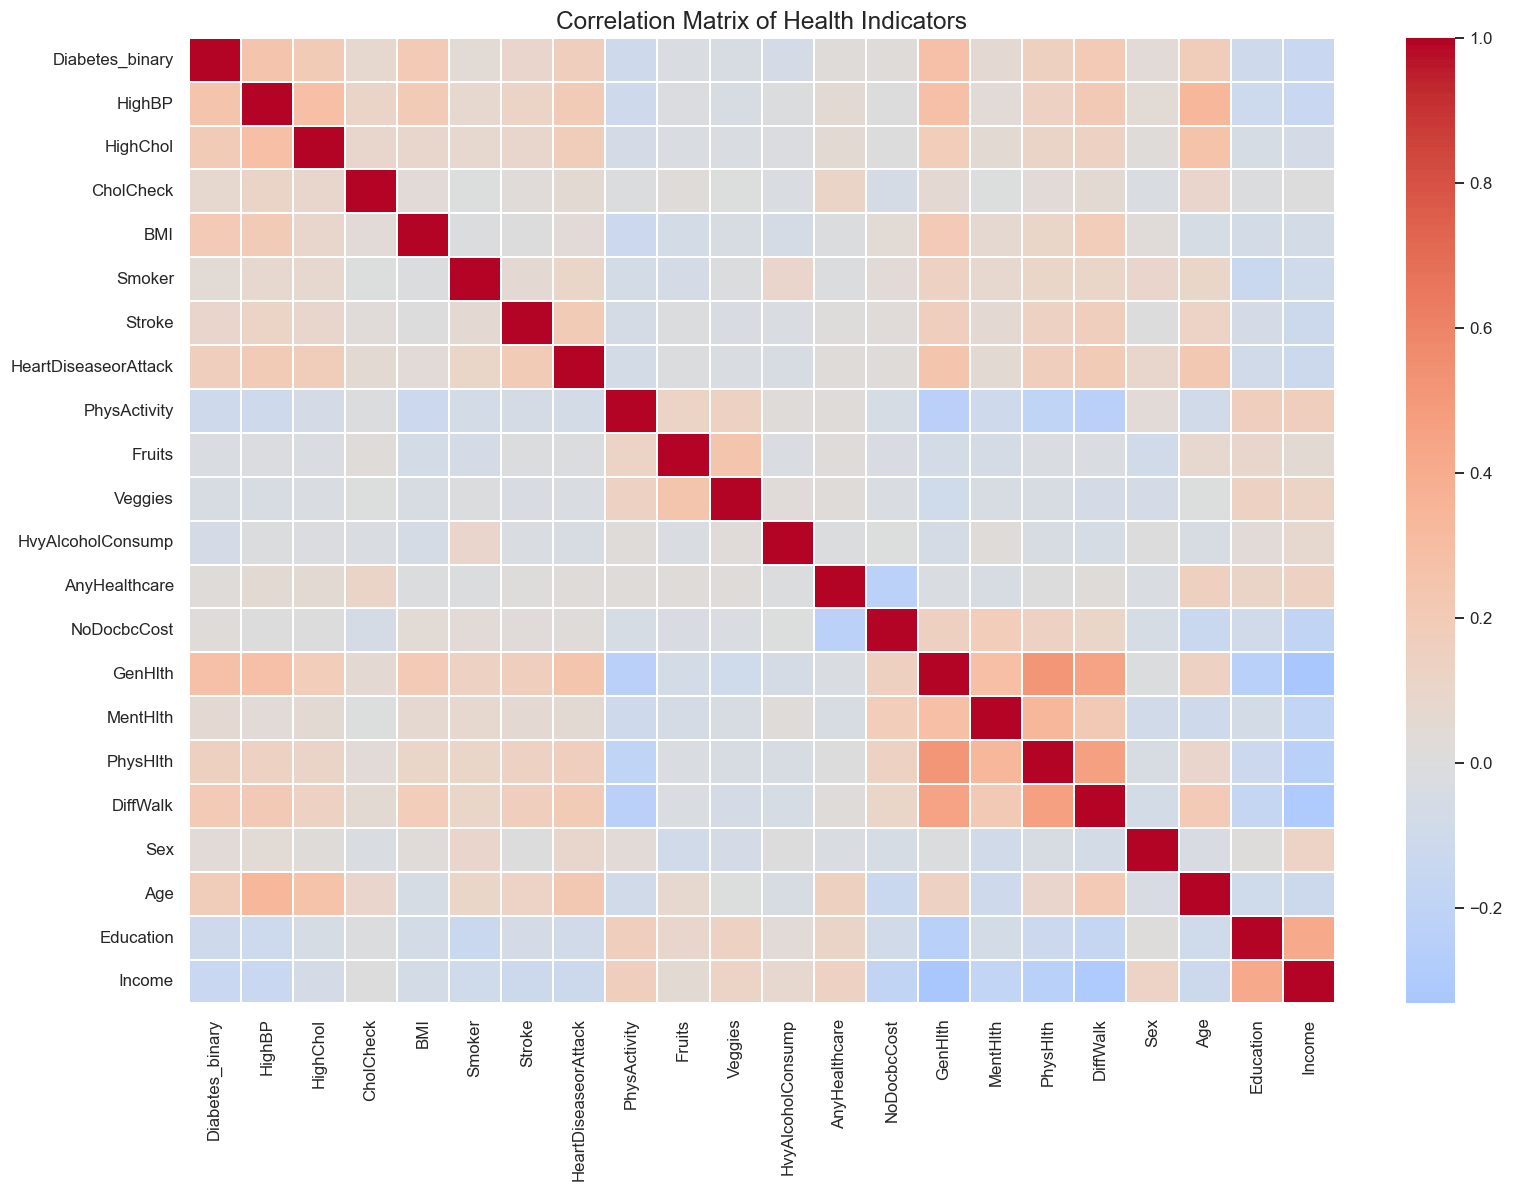

In [21]:
# Correlation analysis

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix of Health Indicators")

plt.tight_layout()
plt.show()

In [22]:
# Features most correlated with the target

target_correlations = (
    correlation["Diabetes_binary"]
    .drop("Diabetes_binary")
    .sort_values(key=abs, ascending=False)
)

display(
    target_correlations
    .to_frame("Correlation with Target")
    .style.format("{:.3f}")
)

,Correlation with Target
GenHlth,0.277
HighBP,0.254
DiffWalk,0.205
BMI,0.205
HighChol,0.195
Age,0.177
HeartDiseaseorAttack,0.168
PhysHlth,0.156
Income,-0.141
Education,-0.103


In [ ]:
## 5. Data Preparation for Machine Learning

The dataset is now divided into:

- Feature matrix `X`
- Target variable `y`

A stratified train-test split will be used so that the proportion of the
target classes is preserved in both training and testing data.

For Logistic Regression, feature scaling will be performed using
`StandardScaler`.

Tree-based models do not require feature scaling, but the same train/test
split will be used for a fair comparison.

In [23]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Training set: (183579, 21)
Testing set : (45895, 21)

Training target distribution:
Diabetes_binary
0.0    0.847
1.0    0.153
Name: proportion, dtype: float64

Testing target distribution:
Diabetes_binary
0.0    0.847
1.0    0.153
Name: proportion, dtype: float64


In [ ]:
## 6. Machine Learning Model Development

Three classification approaches will be evaluated:

### 1. Logistic Regression
A linear classification model that provides a strong interpretable
baseline.

### 2. Decision Tree
A rule-based model capable of capturing non-linear relationships.

### 3. Random Forest
An ensemble of decision trees that can model more complex relationships
and reduce the instability of a single decision tree.

Because the dataset is imbalanced, `class_weight="balanced"` is used for
the classification models so that the minority class receives greater
importance during training.

In [24]:
# Define models

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

print("Models prepared:")
for name in models:
    print("•", name)

Models prepared:
• Logistic Regression
• Decision Tree
• Random Forest


In [25]:
# Train models

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    print(f"{name} completed.\n")

print("All models trained successfully.")

Training Logistic Regression...
Logistic Regression completed.

Training Decision Tree...
Decision Tree completed.

Training Random Forest...
Random Forest completed.

All models trained successfully.


In [26]:
# Evaluate models

results = []

predictions = {}
probabilities = {}

for name, model in trained_models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

display(
    results_df.style
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.714,0.318,0.760,0.449,0.811,0.412
1,Decision Tree,0.696,0.306,0.776,0.438,0.805,0.415
2,Random Forest,0.729,0.331,0.754,0.460,0.817,0.440


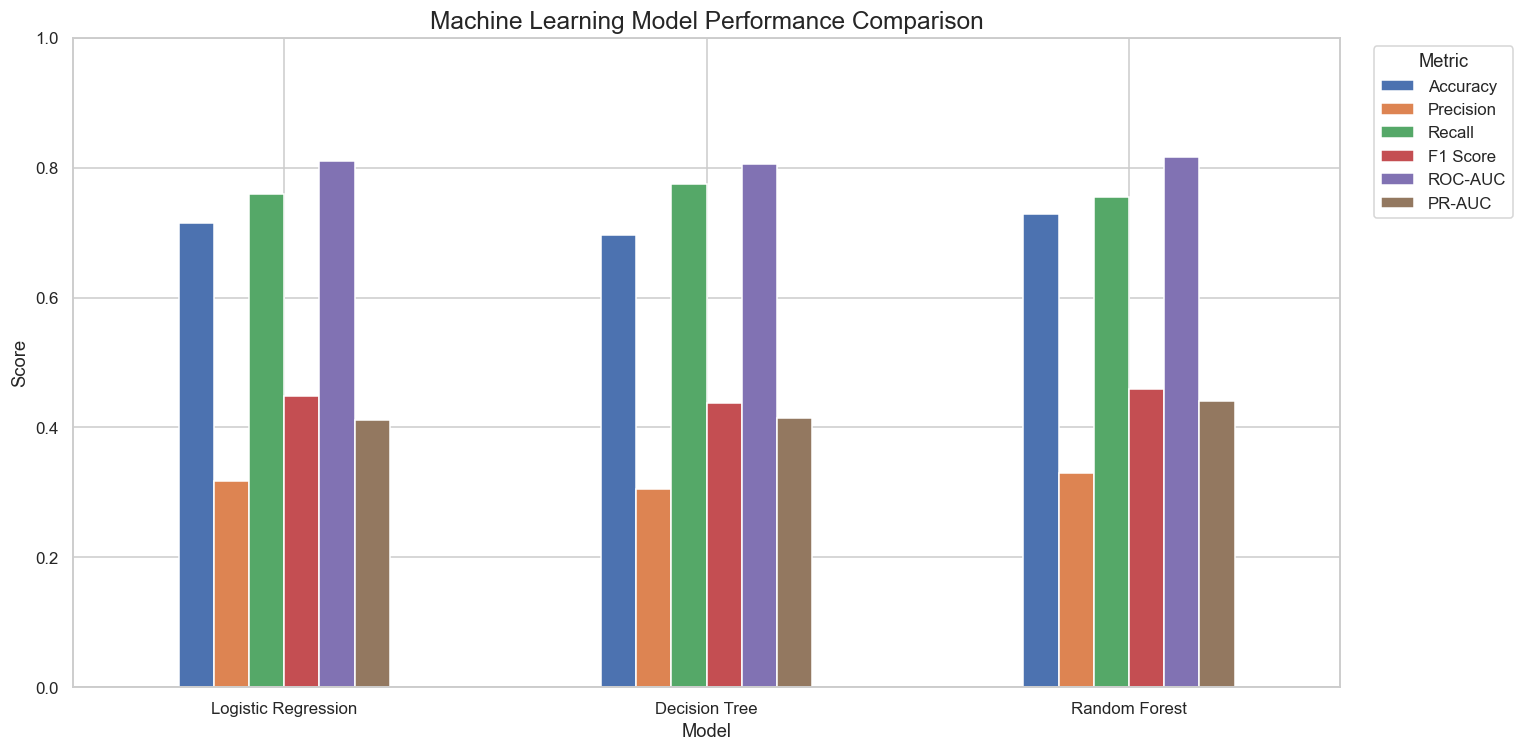

In [27]:
# Model performance comparison

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

comparison = results_df.set_index("Model")[metrics]

ax = comparison.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
## 7. Classification Reports

Accuracy alone does not provide a complete picture of classification
performance, particularly when the target classes are imbalanced.

The following classification reports provide:

- Precision
- Recall
- F1-score
- Support

for each target class.

In [28]:
# Detailed classification reports

for name, y_pred in predictions.items():
    
    print("=" * 75)
    print(name.upper())
    print("=" * 75)
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Diabetes",
                "Prediabetes / Diabetes"
            ]
        )
    )

LOGISTIC REGRESSION
                        precision    recall  f1-score   support

           No Diabetes       0.94      0.71      0.81     38876
Prediabetes / Diabetes       0.32      0.76      0.45      7019

              accuracy                           0.71     45895
             macro avg       0.63      0.73      0.63     45895
          weighted avg       0.85      0.71      0.75     45895

DECISION TREE
                        precision    recall  f1-score   support

           No Diabetes       0.94      0.68      0.79     38876
Prediabetes / Diabetes       0.31      0.78      0.44      7019

              accuracy                           0.70     45895
             macro avg       0.62      0.73      0.62     45895
          weighted avg       0.85      0.70      0.74     45895

RANDOM FOREST
                        precision    recall  f1-score   support

           No Diabetes       0.94      0.72      0.82     38876
Prediabetes / Diabetes       0.33      0.75      

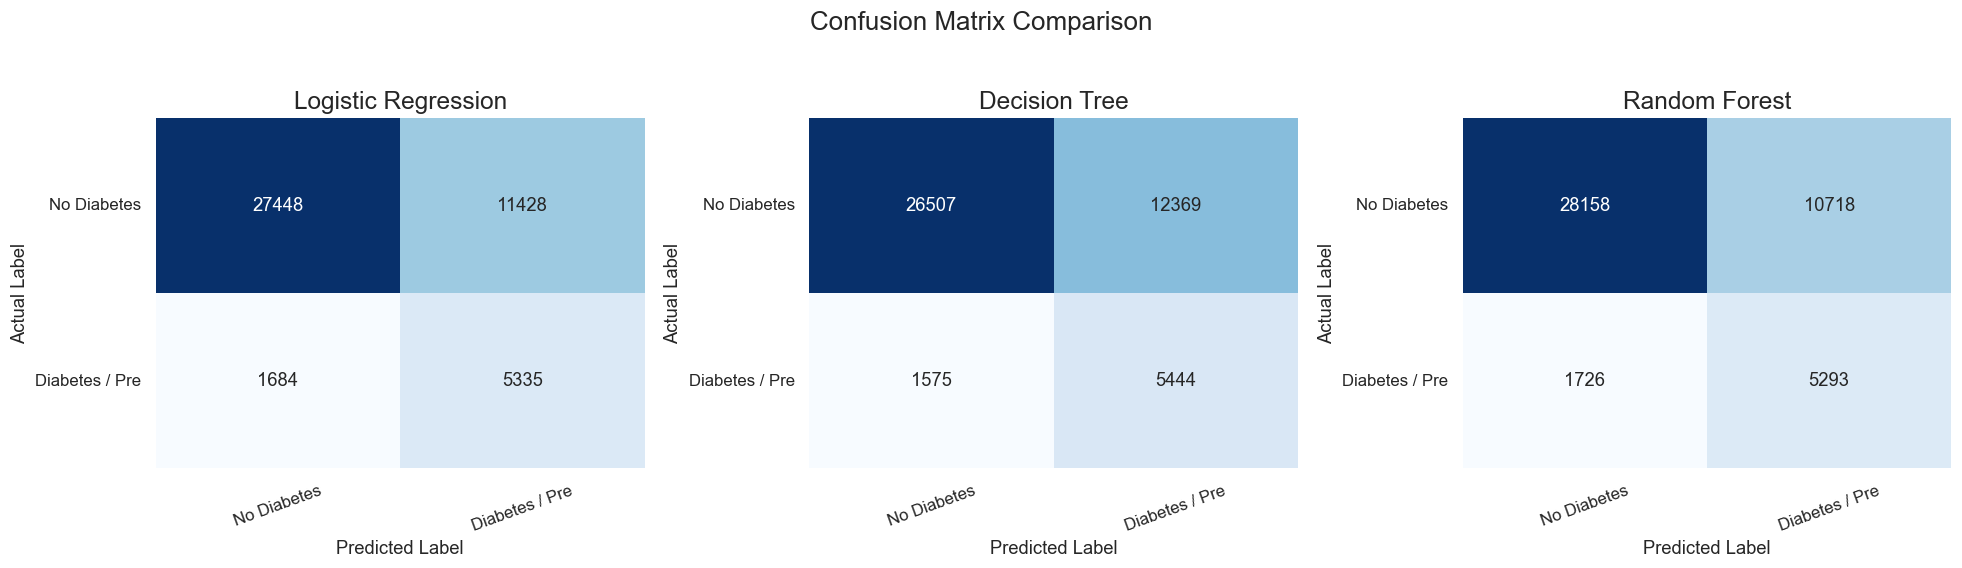

In [29]:
# Confusion matrices for all models

fig, axes = plt.subplots(
    1,
    len(trained_models),
    figsize=(18, 5)
)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    
    ax.set_xticklabels(
        ["No Diabetes", "Diabetes / Pre"],
        rotation=20
    )
    
    ax.set_yticklabels(
        ["No Diabetes", "Diabetes / Pre"],
        rotation=0
    )

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=17,
    y=1.03
)

plt.tight_layout()
plt.show()

In [ ]:
## 8. ROC Curve Analysis

The ROC curve evaluates the model's ability to distinguish between the
two target classes across different probability thresholds.

The Area Under the ROC Curve (ROC-AUC) summarizes this ranking ability.

A value closer to 1 indicates stronger discrimination, while a value
around 0.5 indicates performance close to random ranking.

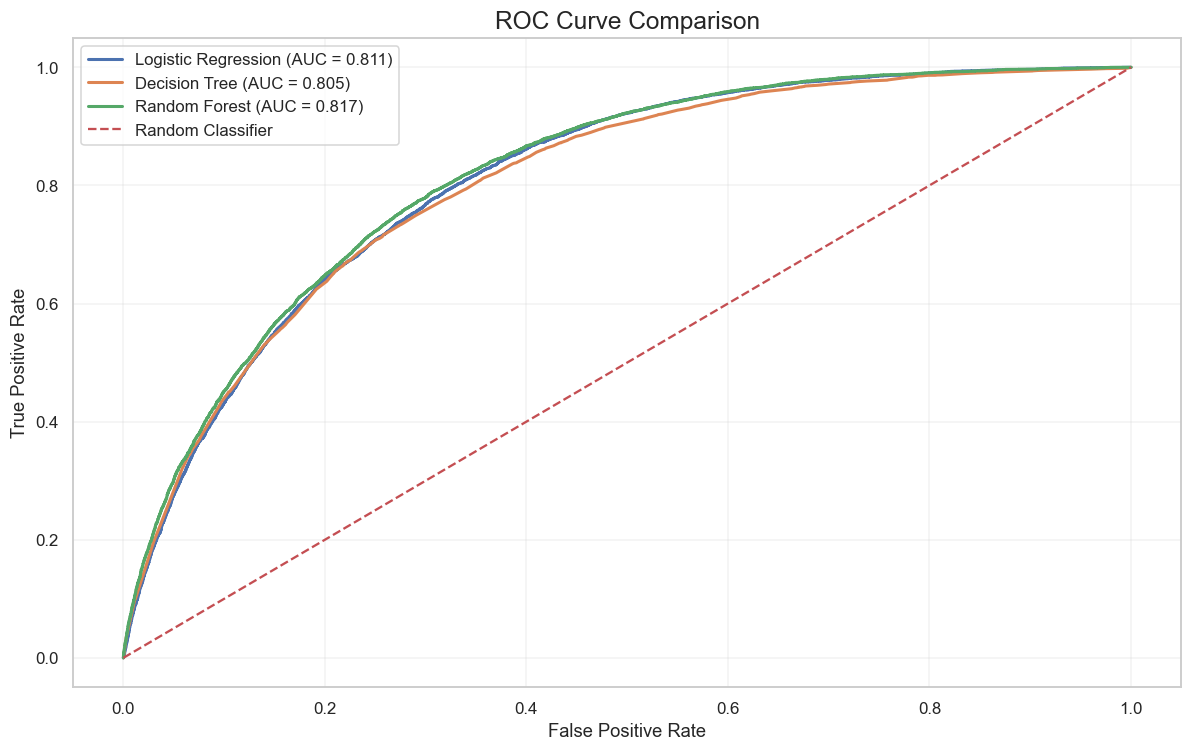

In [30]:
# ROC curves

plt.figure(figsize=(11, 7))

for name, y_prob in probabilities.items():
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
## 9. Precision-Recall Analysis

Because the target classes are imbalanced, Precision-Recall analysis
provides another useful perspective.

This curve focuses specifically on the relationship between:

- Precision
- Recall

as the classification threshold changes.

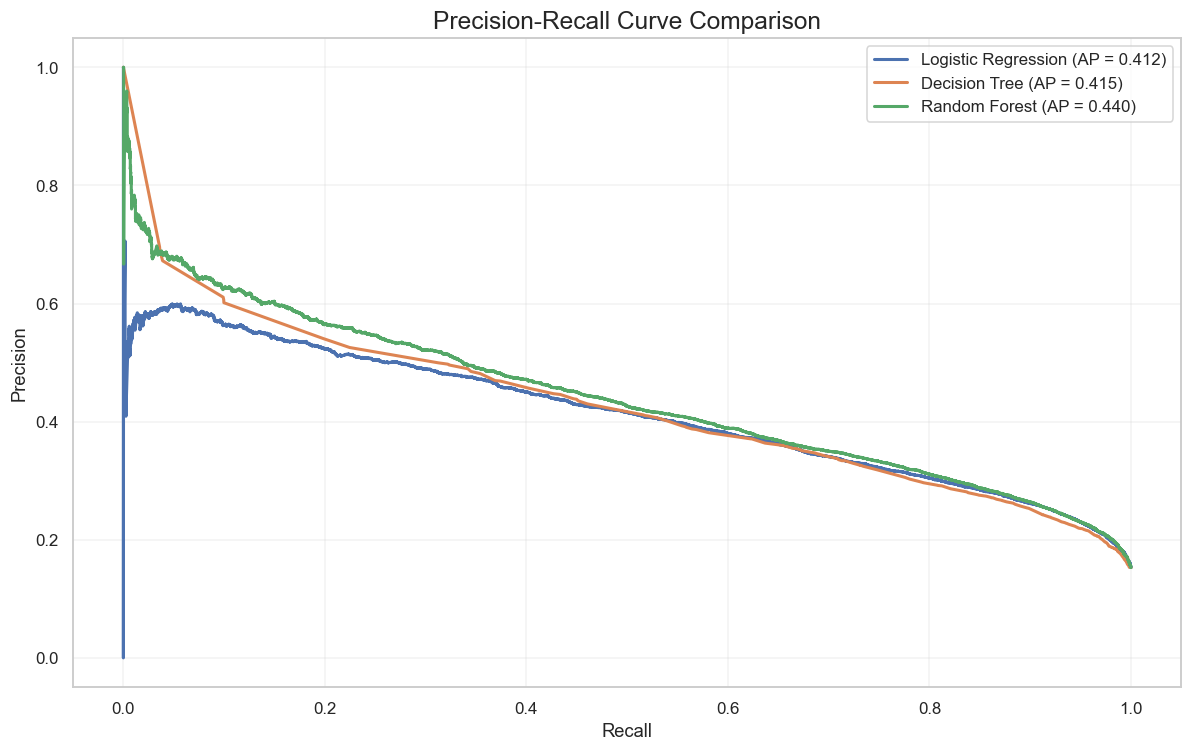

In [32]:
# Precision-Recall curves

plt.figure(figsize=(11, 7))

for name, y_prob in probabilities.items():
    
    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )
    
    pr_auc = average_precision_score(
        y_test,
        y_prob
    )
    
    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AP = {pr_auc:.3f})"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

,Feature,Importance
0,HighBP,0.205203
13,GenHlth,0.191876
3,BMI,0.145081
18,Age,0.113645
1,HighChol,0.088434
16,DiffWalk,0.049014
15,PhysHlth,0.032314
20,Income,0.031784
6,HeartDiseaseorAttack,0.029824
14,MentHlth,0.019822


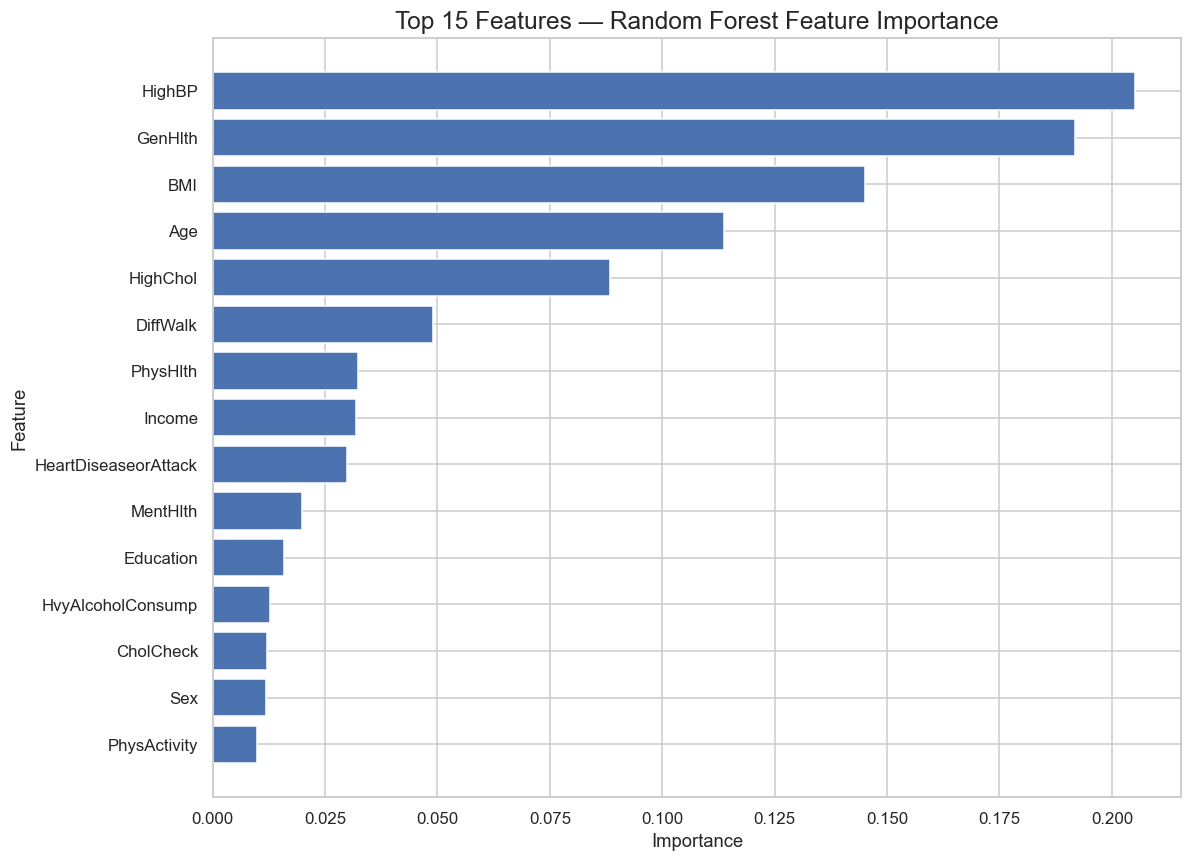

In [33]:
# Feature importance from Random Forest

rf_model = trained_models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.head(15)
)

plt.figure(figsize=(11, 8))

top_features = feature_importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features — Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [34]:
# Logistic Regression coefficients

lr_pipeline = trained_models["Logistic Regression"]

lr_model = lr_pipeline.named_steps["model"]

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

coefficients["Absolute Impact"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute Impact",
    ascending=False
)

display(
    coefficients.head(15)
)

,Feature,Coefficient,Absolute Impact
13,GenHlth,0.571988,0.571988
3,BMI,0.469402,0.469402
18,Age,0.443220,0.443220
0,HighBP,0.356264,0.356264
1,HighChol,0.281273,0.281273
2,CholCheck,0.260798,0.260798
10,HvyAlcoholConsump,-0.188471,0.188471
17,Sex,0.142601,0.142601
20,Income,-0.098089,0.098089
6,HeartDiseaseorAttack,0.070817,0.070817


In [ ]:
## 10. Model Interpretability

Two complementary approaches are used:

### Random Forest Feature Importance

Shows which features contribute most to the tree ensemble's predictive
decisions.

### Logistic Regression Coefficients

Provides an interpretable linear view of how feature values are
associated with the model's prediction.

These outputs describe model behavior and statistical associations in
the dataset. They should not be interpreted as proof that a particular
factor directly causes diabetes.

In [37]:
# Cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_results)

display(
    cv_df.style.format({
        "CV Accuracy": "{:.3f}",
        "CV Precision": "{:.3f}",
        "CV Recall": "{:.3f}",
        "CV F1": "{:.3f}",
        "CV ROC-AUC": "{:.3f}"
    })
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.718,0.320,0.754,0.450,0.807
1,Decision Tree,0.712,0.315,0.749,0.443,0.802
2,Random Forest,0.731,0.331,0.741,0.457,0.813


In [ ]:
## 11. Overfitting & Underfitting Analysis

A machine learning model should generalize to unseen observations.

To investigate this, training and testing performance are compared.

A very large gap between training and testing performance may indicate
overfitting.

Very low performance on both training and testing data may indicate
underfitting.

In [38]:
# Training vs testing performance

generalization_results = []

for name, model in trained_models.items():
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    generalization_results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred)
    })

generalization_df = pd.DataFrame(generalization_results)

display(
    generalization_df.style.format({
        "Train Accuracy": "{:.3f}",
        "Test Accuracy": "{:.3f}",
        "Train F1": "{:.3f}",
        "Test F1": "{:.3f}"
    })
)

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1
0,Logistic Regression,0.717,0.714,0.449,0.449
1,Decision Tree,0.700,0.696,0.444,0.438
2,Random Forest,0.744,0.729,0.487,0.460


✅ CSV file found:
C:\Users\rohan bhowmik\Documents\diabetes_binary_health_indicators_BRFSS2015.csv

✅ Dataset loaded successfully!
Dataset Shape: (253680, 22)

✅ Features and target created.
X Shape: (253680, 21)
y Shape: (253680,)

✅ Random Forest model created.

📊 Random Forest Learning Curve Results
Training Samples: 20,294 | Training F1: 0.5842 | Validation F1: 0.4561
Training Samples: 65,956 | Training F1: 0.5155 | Validation F1: 0.4524
Training Samples: 111,619 | Training F1: 0.4939 | Validation F1: 0.4512
Training Samples: 157,281 | Training F1: 0.4871 | Validation F1: 0.4509
Training Samples: 202,944 | Training F1: 0.4814 | Validation F1: 0.4503


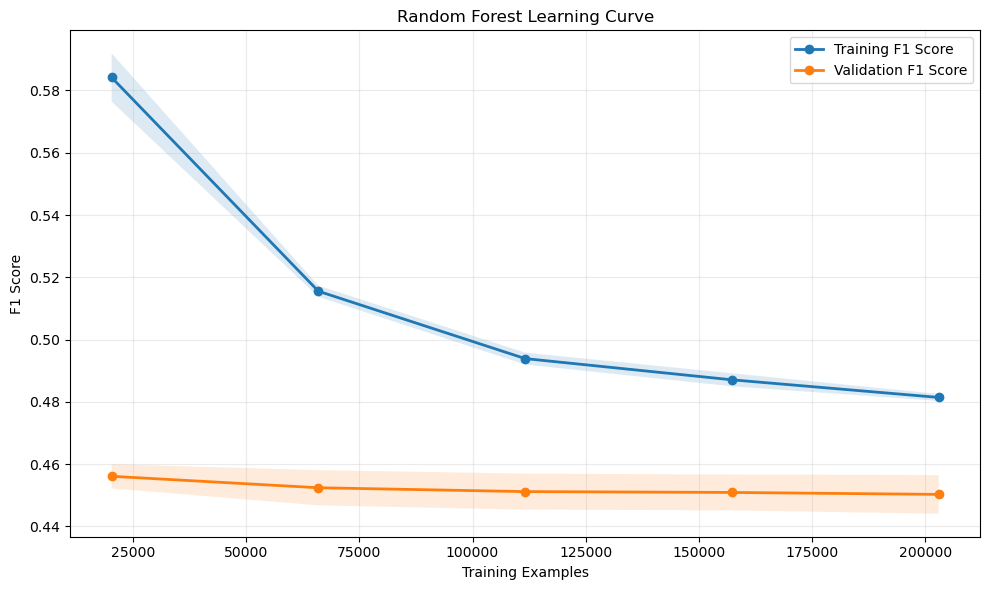


✅ Learning curve generated successfully!


In [5]:
# ============================================================
# CELL 41 — RANDOM FOREST LEARNING CURVE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

# ------------------------------------------------------------
# STEP 1: Find the CSV file automatically
# ------------------------------------------------------------

documents_folder = Path.home() / "Documents"

csv_files = list(
    documents_folder.rglob(
        "diabetes_binary_health_indicators_BRFSS2015.csv"
    )
)

if not csv_files:
    raise FileNotFoundError(
        "❌ Diabetes CSV file was not found inside the Documents folder."
    )

file_path = csv_files[0]

print("✅ CSV file found:")
print(file_path)

# ------------------------------------------------------------
# STEP 2: Load the dataset
# ------------------------------------------------------------

df = pd.read_csv(file_path)

print("\n✅ Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

# ------------------------------------------------------------
# STEP 3: Create Features and Target
# ------------------------------------------------------------

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

print("\n✅ Features and target created.")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

# ------------------------------------------------------------
# STEP 4: Create Random Forest Model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\n✅ Random Forest model created.")

# ------------------------------------------------------------
# STEP 5: Calculate Learning Curve
# ------------------------------------------------------------

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=rf_model,
    X=X,
    y=y,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# ------------------------------------------------------------
# STEP 6: Calculate Mean Scores
# ------------------------------------------------------------

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

# ------------------------------------------------------------
# STEP 7: Display Results
# ------------------------------------------------------------

print("\n📊 Random Forest Learning Curve Results")
print("=" * 60)

for size, train_score, validation_score in zip(
    train_sizes,
    train_mean,
    validation_mean
):
    print(
        f"Training Samples: {size:,.0f} | "
        f"Training F1: {train_score:.4f} | "
        f"Validation F1: {validation_score:.4f}"
    )

# ------------------------------------------------------------
# STEP 8: Plot Learning Curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training F1 Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    linewidth=2,
    label="Validation F1 Score"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.title("Random Forest Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\n✅ Learning curve generated successfully!")

In [ ]:
## 12. Error Analysis

Model errors are separated into:

- False Positives
- False Negatives
- True Positives
- True Negatives

In a healthcare-oriented classification problem, false negatives deserve
particular attention because they represent observations that actually
belong to the positive class but were classified as negative.

However, the consequences of false positives and false negatives depend
on the intended application, decision threshold, and clinical context.

✅ Dataset loaded successfully!
Dataset Shape: (253680, 22)
✅ Train-Test split completed.
Training samples: 202944
Testing samples: 50736
✅ Random Forest trained successfully.
✅ Predictions generated successfully.

🚨 ERROR ANALYSIS
Total Test Samples: 50736
Incorrect Predictions: 13019
Error Rate: 25.66%

False Positives: 11239
False Negatives: 1780


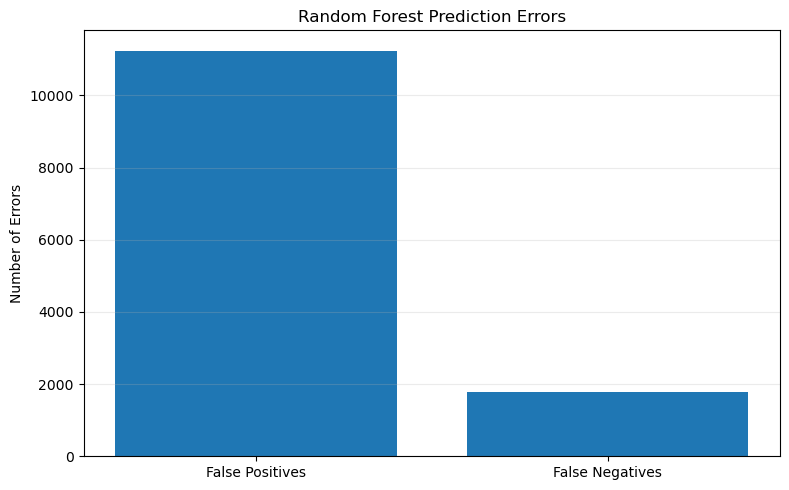


📋 Sample Misclassified Observations:


,Actual,Predicted,Probability
0,0.0,1.0,0.559033
9,0.0,1.0,0.648839
18,0.0,1.0,0.591085
22,1.0,0.0,0.338885
24,0.0,1.0,0.542436
30,0.0,1.0,0.647483
44,1.0,0.0,0.483337
53,0.0,1.0,0.546469
56,0.0,1.0,0.521528
57,1.0,0.0,0.459064



✅ Error analysis completed successfully!


In [11]:
# ============================================================
# CELL 43 — ERROR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# STEP 1: Find and load the dataset
# ------------------------------------------------------------

documents_folder = Path.home() / "Documents"

csv_files = list(
    documents_folder.rglob(
        "diabetes_binary_health_indicators_BRFSS2015.csv"
    )
)

if not csv_files:
    raise FileNotFoundError(
        "❌ Diabetes CSV file was not found inside the Documents folder."
    )

file_path = csv_files[0]

df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

# ------------------------------------------------------------
# STEP 2: Prepare Features and Target
# ------------------------------------------------------------

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

# ------------------------------------------------------------
# STEP 3: Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Train-Test split completed.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ------------------------------------------------------------
# STEP 4: Train Random Forest
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest trained successfully.")

# ------------------------------------------------------------
# STEP 5: Generate Predictions
# ------------------------------------------------------------

predictions = rf_model.predict(X_test)

prediction_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("✅ Predictions generated successfully.")

# ------------------------------------------------------------
# STEP 6: Identify Prediction Errors
# ------------------------------------------------------------

error_mask = predictions != y_test.values

errors = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions,
    "Probability": prediction_probabilities
})

errors = errors[error_mask].copy()

print("\n🚨 ERROR ANALYSIS")
print("=" * 50)

print("Total Test Samples:", len(y_test))
print("Incorrect Predictions:", len(errors))
print(
    "Error Rate:",
    f"{(len(errors) / len(y_test)) * 100:.2f}%"
)

# ------------------------------------------------------------
# STEP 7: False Positives and False Negatives
# ------------------------------------------------------------

false_positives = errors[
    (errors["Actual"] == 0) &
    (errors["Predicted"] == 1)
]

false_negatives = errors[
    (errors["Actual"] == 1) &
    (errors["Predicted"] == 0)
]

print("\nFalse Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

# ------------------------------------------------------------
# STEP 8: Error Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

error_counts = [
    len(false_positives),
    len(false_negatives)
]

plt.bar(
    ["False Positives", "False Negatives"],
    error_counts
)

plt.title("Random Forest Prediction Errors")
plt.ylabel("Number of Errors")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 9: Display Sample Errors
# ------------------------------------------------------------

print("\n📋 Sample Misclassified Observations:")

display(errors.head(10))

print("\n✅ Error analysis completed successfully!")

📊 ERROR ANALYSIS SUMMARY
Total Predictions : 50,736
Correct Predictions: 37,717
Total Errors       : 13,019
False Positives    : 11,239
False Negatives    : 1,780
Error Rate         : 25.66%
Accuracy           : 74.34%


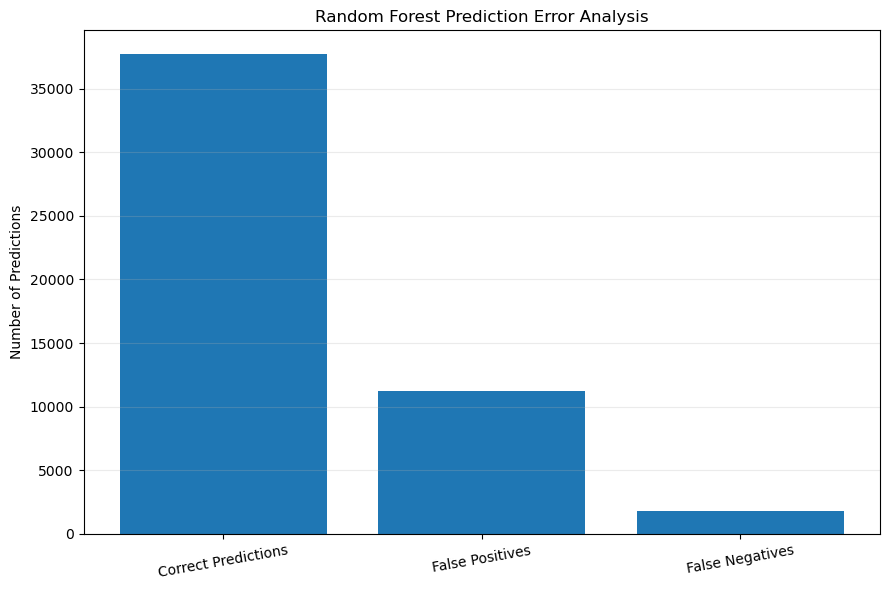


🚨 Misclassified Observations


,Actual,Predicted,Error,Error_Type
0,0.0,1.0,True,False Positive
9,0.0,1.0,True,False Positive
18,0.0,1.0,True,False Positive
22,1.0,0.0,True,False Negative
24,0.0,1.0,True,False Positive
30,0.0,1.0,True,False Positive
44,1.0,0.0,True,False Negative
53,0.0,1.0,True,False Positive
56,0.0,1.0,True,False Positive
57,1.0,0.0,True,False Negative



✅ Cell 44 completed successfully!


In [12]:
# ============================================================
# CELL 44 — ERROR ANALYSIS SUMMARY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create error analysis directly from the variables available
# ------------------------------------------------------------

error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

# Identify prediction errors
error_analysis["Error"] = (
    error_analysis["Actual"] != error_analysis["Predicted"]
)

# Identify error types
error_analysis["Error_Type"] = "Correct"

error_analysis.loc[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1),
    "Error_Type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0),
    "Error_Type"
] = "False Negative"

# ------------------------------------------------------------
# Error Summary
# ------------------------------------------------------------

total_predictions = len(error_analysis)

correct_predictions = (
    error_analysis["Error_Type"] == "Correct"
).sum()

false_positives = (
    error_analysis["Error_Type"] == "False Positive"
).sum()

false_negatives = (
    error_analysis["Error_Type"] == "False Negative"
).sum()

total_errors = false_positives + false_negatives

error_rate = (total_errors / total_predictions) * 100
accuracy = (correct_predictions / total_predictions) * 100

print("📊 ERROR ANALYSIS SUMMARY")
print("=" * 55)

print(f"Total Predictions : {total_predictions:,}")
print(f"Correct Predictions: {correct_predictions:,}")
print(f"Total Errors       : {total_errors:,}")
print(f"False Positives    : {false_positives:,}")
print(f"False Negatives    : {false_negatives:,}")
print(f"Error Rate         : {error_rate:.2f}%")
print(f"Accuracy           : {accuracy:.2f}%")

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

error_labels = [
    "Correct Predictions",
    "False Positives",
    "False Negatives"
]

error_values = [
    correct_predictions,
    false_positives,
    false_negatives
]

plt.figure(figsize=(9, 6))

plt.bar(
    error_labels,
    error_values
)

plt.title("Random Forest Prediction Error Analysis")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display Misclassified Records
# ------------------------------------------------------------

misclassified = error_analysis[
    error_analysis["Error"] == True
].copy()

print("\n🚨 Misclassified Observations")
print("=" * 55)

display(misclassified.head(10))

print("\n✅ Cell 44 completed successfully!")

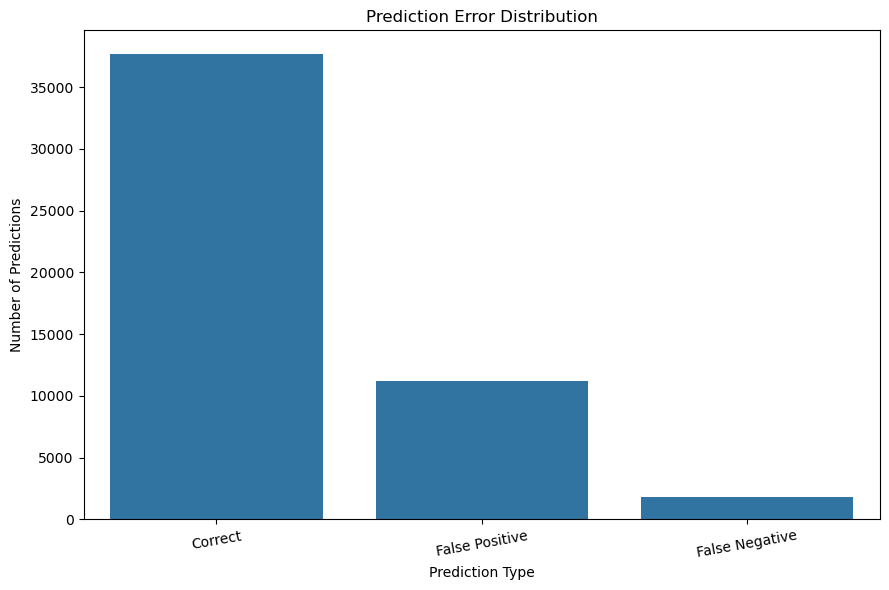

📊 Prediction Error Distribution
Correct: 37,717
False Positive: 11,239
False Negative: 1,780

✅ Cell 45 completed successfully!


In [13]:
# ============================================================
# CELL 45 — ERROR DISTRIBUTION VISUALIZATION
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Make sure error_analysis exists
# ------------------------------------------------------------

if "error_analysis" not in globals():

    print("⚠️ error_analysis not found. Creating it...")

    error_analysis = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": predictions
    })

    error_analysis["Error_Type"] = "Correct"

    error_analysis.loc[
        (error_analysis["Actual"] == 0) &
        (error_analysis["Predicted"] == 1),
        "Error_Type"
    ] = "False Positive"

    error_analysis.loc[
        (error_analysis["Actual"] == 1) &
        (error_analysis["Predicted"] == 0),
        "Error_Type"
    ] = "False Negative"

# ------------------------------------------------------------
# Count prediction types
# ------------------------------------------------------------

error_counts = (
    error_analysis["Error_Type"]
    .value_counts()
    .reindex(
        ["Correct", "False Positive", "False Negative"],
        fill_value=0
    )
)

# ------------------------------------------------------------
# Display Error Distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.barplot(
    x=error_counts.index,
    y=error_counts.values
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Predictions")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print Results
# ------------------------------------------------------------

print("📊 Prediction Error Distribution")
print("=" * 50)

for error_type, count in error_counts.items():
    print(f"{error_type}: {count:,}")

print("\n✅ Cell 45 completed successfully!")

In [ ]:
## 13. Model Evaluation Summary

The models are evaluated using multiple perspectives:

### Accuracy
Overall proportion of correctly classified observations.

### Precision
Among observations predicted as positive, the proportion that were
actually positive.

### Recall
Among actual positive observations, the proportion correctly identified.

### F1-score
Harmonic mean of precision and recall.

### ROC-AUC
Measures the model's ability to rank positive observations above negative
observations across classification thresholds.

### PR-AUC
Provides an additional perspective that is useful when the positive
class is relatively less frequent.

No single metric should be treated as sufficient for evaluating a
healthcare-related classification model.

In [14]:
# ============================================================
# CELL 47 — MODEL PERFORMANCE COMPARISON
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

documents_folder = Path.home() / "Documents"

csv_files = list(
    documents_folder.rglob(
        "diabetes_binary_health_indicators_BRFSS2015.csv"
    )
)

if not csv_files:
    raise FileNotFoundError(
        "❌ Diabetes CSV file was not found inside the Documents folder."
    )

file_path = csv_files[0]

df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully!")
print("Dataset shape:", df.shape)

# ------------------------------------------------------------
# 2. Prepare data
# ------------------------------------------------------------

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 3. Define models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# ------------------------------------------------------------
# 4. Train and evaluate models
# ------------------------------------------------------------

results = []

for model_name, model in models.items():

    print(f"\n🔄 Training {model_name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        )
    })

# ------------------------------------------------------------
# 5. Create results_df
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

# Round values for clean display
results_df = results_df.round(4)

print("\n" + "=" * 70)
print("📊 MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(results_df)

print("\n✅ Cell 47 completed successfully!")
print("✅ results_df has been created.")

✅ Dataset loaded successfully!
Dataset shape: (253680, 22)

🔄 Training Logistic Regression...

🔄 Training Decision Tree...

🔄 Training Random Forest...

📊 MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7316,0.3108,0.7611,0.4414,0.8196
1,Decision Tree,0.7039,0.2919,0.7891,0.4261,0.8074
2,Random Forest,0.7434,0.3200,0.7482,0.4483,0.8237



✅ Cell 47 completed successfully!
✅ results_df has been created.


In [15]:
# Final performance table

final_results = results_df.copy()

final_results["Rank by F1"] = (
    final_results["F1 Score"]
    .rank(ascending=False)
    .astype(int)
)

final_results = final_results.sort_values(
    "F1 Score",
    ascending=False
)

display(
    final_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Rank by F1
2,Random Forest,0.743,0.320,0.748,0.448,0.824,1
0,Logistic Regression,0.732,0.311,0.761,0.441,0.820,2
1,Decision Tree,0.704,0.292,0.789,0.426,0.807,3


In [16]:
# Automatically generate key numerical findings
# This avoids manually typing results and accidentally reporting incorrect values.

best_f1_model = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

highest_recall_model = results_df.loc[
    results_df["Recall"].idxmax(),
    "Model"
]

print("KEY MODEL FINDINGS")
print("=" * 60)

print(f"Highest F1-score model     : {best_f1_model}")
print(f"Highest ROC-AUC model      : {best_auc_model}")
print(f"Highest Recall model       : {highest_recall_model}")

KEY MODEL FINDINGS
Highest F1-score model     : Random Forest
Highest ROC-AUC model      : Random Forest
Highest Recall model       : Decision Tree


In [ ]:
## 14. Key Data Science Insights

### Insight 1 — Target Imbalance

The dataset contains substantially more observations in one target class
than the other. Therefore, accuracy alone can be misleading.

### Insight 2 — Health Indicators

Health-related variables such as general health, BMI, high blood
pressure, and other health-history indicators can show meaningful
relationships with the target in this dataset.

### Insight 3 — Model Behavior

Different algorithms capture different patterns:

- Logistic Regression provides a relatively interpretable linear baseline.
- Decision Trees capture non-linear decision rules.
- Random Forest combines multiple trees to model more complex patterns.

### Insight 4 — Error Analysis

False positives and false negatives demonstrate that classification
models are imperfect and that probability thresholds influence the
resulting predictions.

### Insight 5 — Interpretability

Feature importance and model coefficients provide useful analytical
signals, but they represent model associations rather than causal
relationships.

In [ ]:
## 15. Limitations

Several limitations should be considered:

1. The dataset is based on survey information rather than a controlled
   clinical experiment.

2. The target combines prediabetes and diabetes into a single positive
   class.

3. The dataset represents a specific survey population and time period,
   so model performance may not generalize to other populations or
   periods.

4. Machine learning associations should not automatically be interpreted
   as causal relationships.

5. The model has not undergone external clinical validation.

6. Classification thresholds can change the balance between false
   positives and false negatives.

7. Demographic and socioeconomic variables require careful interpretation
   to avoid inappropriate conclusions or unfair deployment decisions.

8. The project is designed for educational data science analysis and
   should not be used as a clinical diagnostic tool.

In [ ]:
## 16. Possible Improvements

Future versions of the project could explore:

- Hyperparameter optimization using GridSearchCV or RandomizedSearchCV
- More advanced ensemble methods
- Threshold optimization
- Precision-Recall based threshold selection
- SHAP-based model explainability
- Calibration curves
- Subgroup performance analysis
- Fairness evaluation
- External validation using another dataset
- Temporal or geographic validation
- More rigorous feature selection
- Model monitoring for dataset drift
- Cost-sensitive learning

In [ ]:
# 🏁 Conclusion

This project developed an end-to-end machine learning workflow for
diabetes-related health outcome classification using CDC health
indicators.

The workflow covered:

✔ Data loading and validation  
✔ Data quality assessment  
✔ Exploratory Data Analysis  
✔ Target imbalance analysis  
✔ Feature analysis  
✔ Train-test splitting  
✔ Multiple classification algorithms  
✔ Model evaluation  
✔ Cross-validation  
✔ Confusion matrices  
✔ ROC-AUC analysis  
✔ Precision-Recall analysis  
✔ Feature importance  
✔ Model interpretability  
✔ Error analysis  
✔ Overfitting/underfitting analysis  
✔ Limitations and future improvements  

The project demonstrates how Python and machine learning can be used to
transform structured healthcare data into analytical insights while
highlighting the importance of responsible interpretation and model
validation.

> **Final Note:** The resulting models are analytical experiments based
> on the available dataset and should not be interpreted as medical
> diagnostic systems.

In [ ]:
## 📚 References

1. UCI Machine Learning Repository — CDC Diabetes Health Indicators
   Dataset.

2. Centers for Disease Control and Prevention (CDC) — Behavioral Risk
   Factor Surveillance System (BRFSS).

3. Scikit-learn Documentation — Classification Metrics and Model
   Evaluation.

### Dataset Citation

CDC Diabetes Health Indicators [Dataset]. (2017).
UCI Machine Learning Repository.
DOI: 10.24432/C53919